### Wczytanie danych

In [1]:
from pathlib import Path
import pandas as pd

data_dir = Path("dataset")

train_df = pd.read_pickle(data_dir / "dataset_train.pkl")
val_df = pd.read_pickle(data_dir / "dataset_val.pkl")

train_df.info()

<class 'pandas.DataFrame'>
Index: 203 entries, 53 to 228
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID_nagrania  203 non-null    str    
 1   sygnał       203 non-null    object 
 2   źródło       203 non-null    str    
 3   label        203 non-null    int64  
 4   qSQI         203 non-null    float64
 5   cSQI         203 non-null    float64
 6   kurtosis     203 non-null    float64
dtypes: float64(3), int64(1), object(1), str(2)
memory usage: 12.7+ KB


# Sieć neuronowa

## CNN

Na samym sygnale zastosowano **jednowymiarową sieć splotową (1D CNN)** składającą się z trzech warstw konwolucyjnych, z funkcją aktywacji **ReLU** oraz **max poolingiem** w celu zmniejszenia długości sekwencji. Na końcu sygnał jest **spłaszczany (flatten)** i przekazywany do warstwy **w pełni połączonej (fully connected)** w celu klasyfikacji do odpowiedniej liczby klas.


===== FOLD 1 =====
Epoch 5/25 | Train acc: 0.7037 | Val acc: 0.8293
Epoch 10/25 | Train acc: 0.9568 | Val acc: 0.8537
Epoch 15/25 | Train acc: 0.9877 | Val acc: 0.9268
Epoch 20/25 | Train acc: 1.0000 | Val acc: 0.8780
Epoch 25/25 | Train acc: 1.0000 | Val acc: 0.9024

===== FOLD 2 =====
Epoch 5/25 | Train acc: 0.7901 | Val acc: 0.7805
Epoch 10/25 | Train acc: 0.9074 | Val acc: 0.7805
Epoch 15/25 | Train acc: 0.9444 | Val acc: 0.9268
Epoch 20/25 | Train acc: 0.9877 | Val acc: 0.9268
Epoch 25/25 | Train acc: 1.0000 | Val acc: 0.9512

===== FOLD 3 =====
Epoch 5/25 | Train acc: 0.7654 | Val acc: 0.6585
Epoch 10/25 | Train acc: 0.8272 | Val acc: 0.7805
Epoch 15/25 | Train acc: 0.9630 | Val acc: 0.9024
Epoch 20/25 | Train acc: 0.9877 | Val acc: 0.8780
Epoch 25/25 | Train acc: 1.0000 | Val acc: 0.9024

===== FOLD 4 =====
Epoch 5/25 | Train acc: 0.7239 | Val acc: 0.6500
Epoch 10/25 | Train acc: 0.8834 | Val acc: 0.8000
Epoch 15/25 | Train acc: 0.9693 | Val acc: 0.7750
Epoch 20/25 | Train acc:

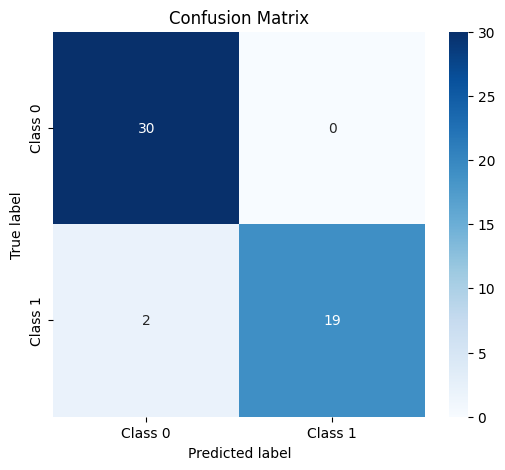

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold

torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)

def prepare_signals(df):
    signals = []
    for idx, s in enumerate(df['sygnał']):
        arr = np.array(s, dtype=np.float32).flatten()
        target_len = 2500
        if arr.size == 0:
            print(f"Warning: Empty signal at index {idx}, skipping.")
            continue
        if len(arr) < target_len:
            arr = np.pad(arr, (0, target_len - len(arr)))
        else:
            arr = arr[:target_len]
        if arr.shape != (target_len,):
            print(f"Warning: Signal at index {idx} has shape {arr.shape}, expected ({target_len},)")
            continue
        signals.append(arr)
    if len(signals) == 0:
        raise ValueError("No valid signals found in the DataFrame.")
    signals = np.stack(signals)
    signals = signals[:, np.newaxis, :]
    return torch.tensor(signals)

def prepare_labels(df):
    return torch.tensor(df['label'].values, dtype=torch.long)

def get_data(train_df, val_df):
    X_train = prepare_signals(train_df)
    X_val = prepare_signals(val_df)
    y_train = prepare_labels(train_df)
    y_val = prepare_labels(val_df)
    return X_train, X_val, y_train, y_val

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=7, padding=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(2)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * (2500 // 8), num_classes)
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

def train_fold(X_train, y_train, X_val, y_val, num_classes=2, num_epochs=25, batch_size=32, lr=1e-3, device=None, print_every=5):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_ds = TensorDataset(X_train, y_train)
    val_ds   = TensorDataset(X_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)

    model = CNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
        train_acc = correct / total

        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == yb).sum().item()
                val_total += yb.size(0)
        val_acc = val_correct / val_total

        if epoch % print_every == 0 or epoch == num_epochs:
            print(f"Epoch {epoch}/{num_epochs} | Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}")

    return model

def train_cnn(X_all, y_all, num_classes=2, num_epochs=25, batch_size=32, lr=1e-3, n_splits=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold = 1
    for train_idx, val_idx in skf.split(X_all, y_all.numpy()):
        print(f"\n===== FOLD {fold} =====")
        X_train, y_train = X_all[train_idx], y_all[train_idx]
        X_test, y_test     = X_all[val_idx], y_all[val_idx]

        _ = train_fold(X_train, y_train, X_test, y_test, num_classes, num_epochs, batch_size, lr, device)

        fold += 1

    print("\nTraining final model on full dataset...")
    final_model = train_fold(X_all, y_all, X_all, y_all, num_classes, num_epochs, batch_size, lr, device)
    return final_model, device

def evaluate_cnn(model, X_eval, y_eval, device, class_names=None):
    model.eval()
    ds = TensorDataset(X_eval, y_eval)
    loader = DataLoader(ds, batch_size=32)
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            outputs = model(xb)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(yb.numpy())
            y_pred.extend(predicted.cpu().numpy())

    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    if class_names is None:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Confusion Matrix')
    plt.show()

X_train = prepare_signals(train_df)
y_train = prepare_labels(train_df)

model, device = train_cnn(X_train, y_train)

X_val = prepare_signals(val_df)
y_val = prepare_labels(val_df)

evaluate_cnn(model, X_val, y_val, device)

## CNN jako ekstraktor cech

Do ekstrakcji cech z sygnałów wykorzystano wcześniej wytrenowaną **jednowymiarową sieć splotową (1D CNN)**. Sieć została użyta jako **feature extractor**, gdzie wyjście z warstw konwolucyjnych i poolingowych jest spłaszczane i traktowane jako reprezentacja cech sygnału.  

Następnie uzyskane cechy zostały połączone z cechami jakości i wykorzystane jako wejście do poniższych klasyfikatorów.

In [3]:
from sklearn.preprocessing import StandardScaler

class CNN_FeatureExtractor(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.features = nn.Sequential(
            trained_model.conv1,
            trained_model.relu1,
            trained_model.pool1,
            trained_model.conv2,
            trained_model.relu2,
            trained_model.pool2,
            trained_model.conv3,
            trained_model.relu3,
            trained_model.pool3,
            trained_model.flatten
        )
    def forward(self, x):
        return self.features(x)
    
def extract_features(model, X, batch_size=32, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    features = []
    loader = DataLoader(TensorDataset(X), batch_size=batch_size)
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            feats = model(xb)
            features.append(feats.cpu().numpy())
    return np.vstack(features)

def get_quality_features(df):
    quality_cols = ['qSQI', 'cSQI', 'kurtosis']
    return df[quality_cols].values.astype(np.float32)

def evaluate_classifier(clf, X_features, y_true, class_names=None):
    y_pred = clf.predict(X_features)
    
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    
    if class_names is None:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

scaler = StandardScaler()

feature_extractor = CNN_FeatureExtractor(model).to(device).eval()
features_train = extract_features(feature_extractor, X_train, device=device)
quality_features_train = get_quality_features(train_df)
X_train_features = scaler.fit_transform(np.hstack([features_train, quality_features_train]))

features_val = extract_features(feature_extractor, X_val, device=device)
quality_features_val = get_quality_features(val_df)
X_val_features = scaler.transform(np.hstack([features_val, quality_features_val]))

### KNN


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.37      0.54        30
           1       0.53      1.00      0.69        21

    accuracy                           0.63        51
   macro avg       0.76      0.68      0.61        51
weighted avg       0.80      0.63      0.60        51



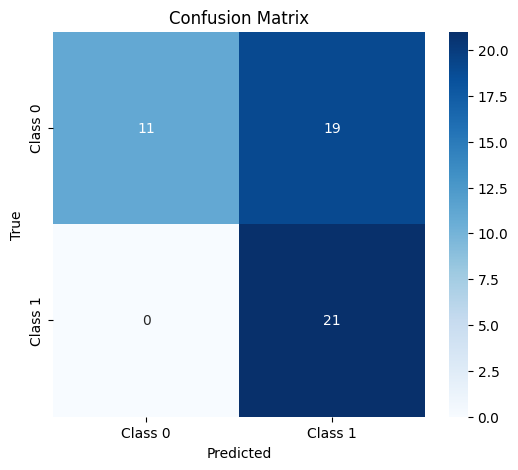

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_features, y_train)

evaluate_classifier(knn, X_val_features, y_val)

KNN nie radzi sobie z wysoką wymiarowością. Spróbujmy ją obniżyć z PCA.

Best params:  {'knn__n_neighbors': 3, 'pca__n_components': 2}
Best score (CV): 0.8817073170731706

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.90      0.84        30
           1       0.82      0.67      0.74        21

    accuracy                           0.80        51
   macro avg       0.81      0.78      0.79        51
weighted avg       0.81      0.80      0.80        51



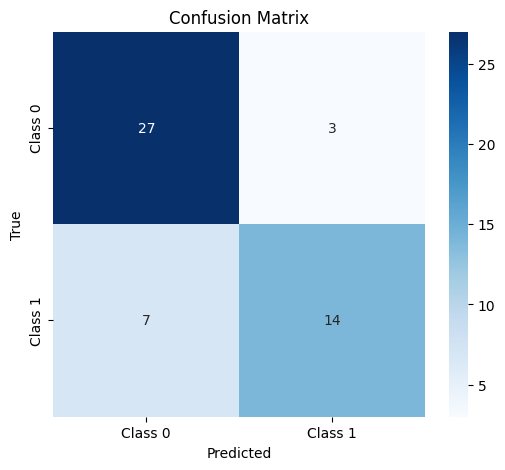

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('pca', PCA()),
    ('knn', KNeighborsClassifier(weights='distance'))
])

param_grid = {
    'pca__n_components': [2, 3, 4, 6, 7, 8, 9, 10],
    'knn__n_neighbors': [1, 3, 5, 7, 9]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_features, y_train)

print("Best params: ", grid.best_params_)
print("Best score (CV):", grid.best_score_)

evaluate_classifier(grid.best_estimator_, X_val_features, y_val)

### SVM

Best params:  {'pca__n_components': 100, 'svm__C': 1, 'svm__gamma': 'scale'}
Best CV score: 0.9413414634146342

Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.90      0.95        21

    accuracy                           0.96        51
   macro avg       0.97      0.95      0.96        51
weighted avg       0.96      0.96      0.96        51



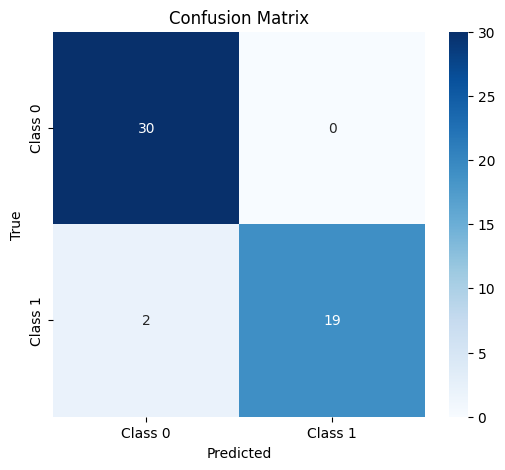

In [6]:
from sklearn.svm import SVC

pipeline = Pipeline([
    ('pca', PCA()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

param_grid = {
    'pca__n_components': [10, 20, 50, 100],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_features, y_train)

print("Best params: ", grid.best_params_)
print("Best CV score:", grid.best_score_)

evaluate_classifier(grid.best_estimator_, X_val_features, y_val)

### Random Forest


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.97      0.91        30
           1       0.94      0.76      0.84        21

    accuracy                           0.88        51
   macro avg       0.90      0.86      0.87        51
weighted avg       0.89      0.88      0.88        51



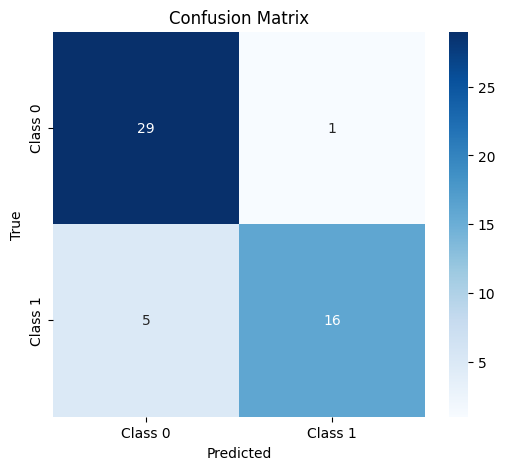

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf.fit(X_train_features, y_train)

evaluate_classifier(rf, X_val_features, y_val)

### MLP (Multi-Layer Perceptron)

Best params:  {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (100, 50), 'pca__n_components': 100}
Best CV score: 0.9265853658536585

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.95      0.98        21

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



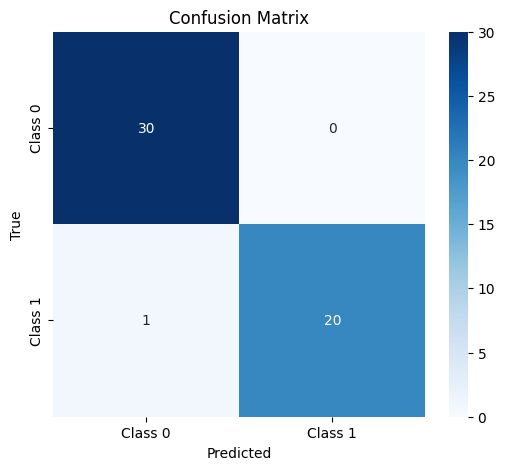

In [8]:
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('pca', PCA()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

param_grid = {
    'pca__n_components': [10, 20, 50, 100],
    'mlp__hidden_layer_sizes': [(50,), (100,), (100,50)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_features, y_train)

print("Best params: ", grid.best_params_)
print("Best CV score:", grid.best_score_)

evaluate_classifier(grid.best_estimator_, X_val_features, y_val)